In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('map_data.csv')

In [3]:
X = data[['x', 'y']].values

Y = data['label'].values

In [4]:
import torch
import torch.nn as nn
import torch.functional as F 
import torch.optim as optim

In [ ]:
# nn class

class Deepnet(nn.Module):
    def __init__(self, input_size =2, h1_size = 2, h2_size = 2, output_size = 2):
        super(Deepnet, self).__init__()
        self.h1 = nn.Linear(input_size, h1_size)
        self.bn1 = nn.BatchNorm1d(h1_size)
        self.h2 = nn.Linear(h1_size, h2_size)
        self.bn2 = nn.BatchNorm1d(h2_size)
        self.output = nn.Linear(h2_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.h1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.h2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.output(x)
        return x 
    
deepmodel = Deepnet(input_size = 2, h1_size = 4, h2_size = 4, output_size = 2)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(deepmodel.parameters(), lr = 0.01)

for epoch in range(200):
    # forward pass 
    inputs = torch.tensor(X, dtype = torch.float32)
    labels = torch.tensor(Y, dtype = torch.long)
    outputs = deepmodel(inputs)

    # loss
    loss = loss_fn(outputs, labels)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {loss:.4f}")


Epoch 0: loss = 0.8117
Epoch 10: loss = 0.5605
Epoch 20: loss = 0.4327
Epoch 30: loss = 0.3702
Epoch 40: loss = 0.3417
Epoch 50: loss = 0.3258
Epoch 60: loss = 0.3166
Epoch 70: loss = 0.3076
Epoch 80: loss = 0.2986
Epoch 90: loss = 0.2911
Epoch 100: loss = 0.2853
Epoch 110: loss = 0.2809
Epoch 120: loss = 0.2770
Epoch 130: loss = 0.2731
Epoch 140: loss = 0.2694
Epoch 150: loss = 0.2656
Epoch 160: loss = 0.2620
Epoch 170: loss = 0.2584
Epoch 180: loss = 0.2555
Epoch 190: loss = 0.2533
Epoch 200: loss = 0.2517


KeyboardInterrupt: 

c:\Users\Jakkala\anaconda3\envs\ml-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


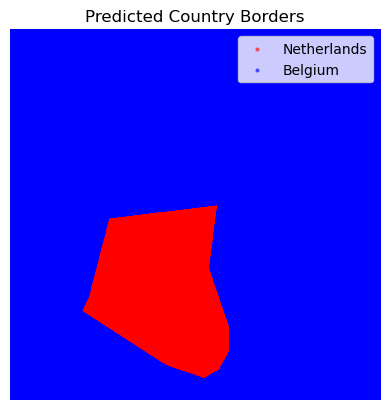

In [6]:
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg 

img = mpimg.imread('Baarle-Nassau_Baarle-Hertog.png')
plt.imshow(img)
plt.axis('off')

inputs = torch.tensor(X, dtype = torch.float32)

with torch.no_grad():
    outputs = deepmodel(inputs)
    preds = torch.argmax(outputs, dim = 1).numpy()

plt.scatter(X[preds == 1, 0], X[preds == 1, 1], c='red', s=4, label='Netherlands', alpha=0.5)
plt.scatter(X[preds == 0, 0], X[preds == 0, 1], c='blue', s=4, label='Belgium', alpha=0.5)
plt.legend()
plt.title("Predicted Country Borders")
plt.show()